# Gradient Descent in Two Variables — Part 2 (The Algorithm)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture defining the full **multivariable
gradient-descent** algorithm (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- the geometric picture: two tangents → two gradient-component vectors on the floor →
  their sum is the **gradient**
- the gradient is the direction of **steepest ascent**, so we step along $-\nabla f$
- the update rule $(x_k, y_k) = (x_{k-1}, y_{k-1}) - \alpha\,\nabla f$ — identical to the
  1D rule with derivative → gradient
- the worked sauna example from $(0.5, 0.6)$ with $\alpha = 0.05$
- a Python implementation converging to the minimum, plus the local-minima drawback and
  random restarts

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradient Descent in Two Variables — Part 1*.

## 1. From random steps to the gradient

> *"In the previous video there were a lot of random steps. Now we'll do it more exactly
> and mathematically — just like we did with one variable, but in two."*

We start at an initial position with **two** coordinates $(x_0, y_0)$, and instead of the
single derivative we use the **gradient**.

## 2. The geometric picture

At the starting point there are now **two tangents** — one per variable:

- The $x$-tangent might be **steep** → its gradient component is a **big** vector drawn on
  the floor, pointing where the function increases.
- The $y$-tangent might be **flatter** → a **smaller** vector.

> *"Take the sum of these two vectors — the vector with the two coordinates — and that is
> the gradient."*

$$
\nabla f = \begin{bmatrix} \partial f/\partial x \\ \partial f/\partial y \end{bmatrix}.
$$

### Ascent vs. descent

> *"The gradient is the direction of gradient ascent... but we don't want to get hotter,
> we want to get colder, so we take the direction of the negative gradient."*

$-\nabla f$ is the direction that, in one tiny step, takes you **down** the fastest.

## 3. The update rule

Take a small step along $-\nabla f$, scaled by the learning rate $\alpha$:

$$
\begin{bmatrix} x_k \\ y_k \end{bmatrix}
=
\begin{bmatrix} x_{k-1} \\ y_{k-1} \end{bmatrix}
- \alpha\, \nabla f(x_{k-1}, y_{k-1}).
$$

> *"Notice this is exactly the same as gradient descent in one variable, except instead of
> the derivative we take the gradient."*

**The algorithm:**

1. Choose a learning rate $\alpha$ and a starting point $(x_0, y_0)$.
2. Update: $\mathbf{x}_k = \mathbf{x}_{k-1} - \alpha\,\nabla f(\mathbf{x}_{k-1})$.
3. Repeat until the movement is tiny (you're close enough to the minimum).

## 4. Worked example: the sauna

The temperature is

$$
T(x,y) = 85 - \frac{1}{90}\,x^2(x-6)\,y^2(y-6),
$$

with gradient (computed in an earlier lecture)

$$
\nabla T = \begin{bmatrix} -\frac{1}{90}\,x(3x-12)\,y^2(y-6) \\[2mm]
                           -\frac{1}{90}\,x^2(x-6)\,y(3y-12) \end{bmatrix}.
$$

Start at $(0.5, 0.6)$ with learning rate $\alpha = 0.05$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def T(x, y):
    return 85 - (1/90) * x**2 * (x - 6) * y**2 * (y - 6)

def grad_T(x, y):
    Tx = -(1/90) * x * (3*x - 12) * y**2 * (y - 6)
    Ty = -(1/90) * x**2 * (x - 6) * y * (3*y - 12)
    return np.array([Tx, Ty])

start = np.array([0.5, 0.6])
alpha = 0.05

g0 = grad_T(*start)
x1 = start - alpha * g0
print(f"gradient at (0.5, 0.6) = ({g0[0]:.4f}, {g0[1]:.4f})")
print(f"new point x1 = ({x1[0]:.4f}, {x1[1]:.4f})   (lecture: 0.5057, 0.6047)")

gradient at (0.5, 0.6) = (-0.1134, -0.0935)
new point x1 = (0.5057, 0.6047)   (lecture: 0.5057, 0.6047)


## 5. Implementing 2D gradient descent

In [2]:
def gradient_descent_2d(grad, start, alpha=0.05, n_steps=5000, tol=1e-8):
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    for _ in range(n_steps):
        step = alpha * grad(*pos)
        pos = pos - step
        path.append(pos.copy())
        if np.linalg.norm(step) < tol:   # barely moving -> stop
            break
    return pos, np.array(path)

final, path = gradient_descent_2d(grad_T, start=(0.5, 0.6), alpha=0.05)
print(f"converged to ({final[0]:.4f}, {final[1]:.4f}), T = {T(*final):.4f}")
print(f"analytical minimum: (4, 4), T = {T(4,4):.4f}")
print(f"iterations: {len(path) - 1}")
print(f"first few points: {np.round(path[:4], 4).tolist()}")

converged to (4.0000, 4.0000), T = 73.6222
analytical minimum: (4, 4), T = 73.6222
iterations: 143
first few points: [[0.5, 0.6], [0.5057, 0.6047], [0.5115, 0.6095], [0.5174, 0.6144]]


### Visualizing the descent on the sauna heat-map

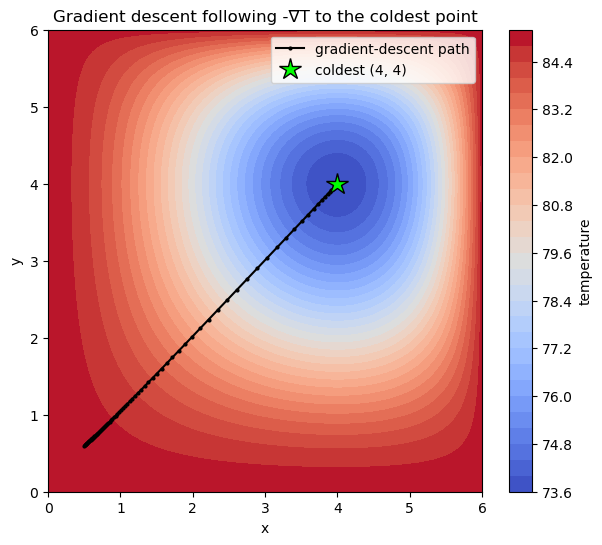

In [3]:
gx = np.linspace(0, 6, 200)
gy = np.linspace(0, 6, 200)
X, Y = np.meshgrid(gx, gy)
Z = T(X, Y)

plt.figure(figsize=(7, 6))
hm = plt.contourf(X, Y, Z, levels=30, cmap="coolwarm")
plt.colorbar(hm, label="temperature")
plt.plot(path[:, 0], path[:, 1], "o-", color="black", markersize=2,
         label="gradient-descent path")
plt.plot(4, 4, "*", color="lime", markersize=16, markeredgecolor="black",
         label="coldest (4, 4)")
plt.title("Gradient descent following -∇T to the coldest point")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 6. The same drawbacks as 1D: local minima

> *"Gradient descent in two or more variables still has the same drawbacks — you may
> accidentally get into a local minimum. The way to overcome it, at least with high
> probability, is to start at very different places."*

We illustrate with a surface that has a **local** and a **global** minimum:

$$
f(x,y) = 3x^4 + 4x^3 - 12x^2 + y^2,
$$

whose global minimum is at $(-2, 0)$ and a shallower local minimum at $(1, 0)$.

In [4]:
def f_multi(x, y):
    return 3*x**4 + 4*x**3 - 12*x**2 + y**2

def grad_multi(x, y):
    return np.array([12*x**3 + 12*x**2 - 24*x, 2*y])

starts = [(-1.5, 2.0), (0.5, -2.0), (2.0, 1.5)]
paths = []
for s in starts:
    fin, p = gradient_descent_2d(grad_multi, s, alpha=0.01, n_steps=2000)
    paths.append(p)
    where = "GLOBAL (-2,0)" if fin[0] < -1 else "local (1,0)"
    print(f"start {str(s):>12} -> ({fin[0]:6.3f}, {fin[1]:6.3f}), f={f_multi(*fin):7.3f}  {where}")

start  (-1.5, 2.0) -> (-2.000,  0.000), f=-32.000  GLOBAL (-2,0)
start  (0.5, -2.0) -> ( 1.000, -0.000), f= -5.000  local (1,0)
start   (2.0, 1.5) -> ( 1.000,  0.000), f= -5.000  local (1,0)


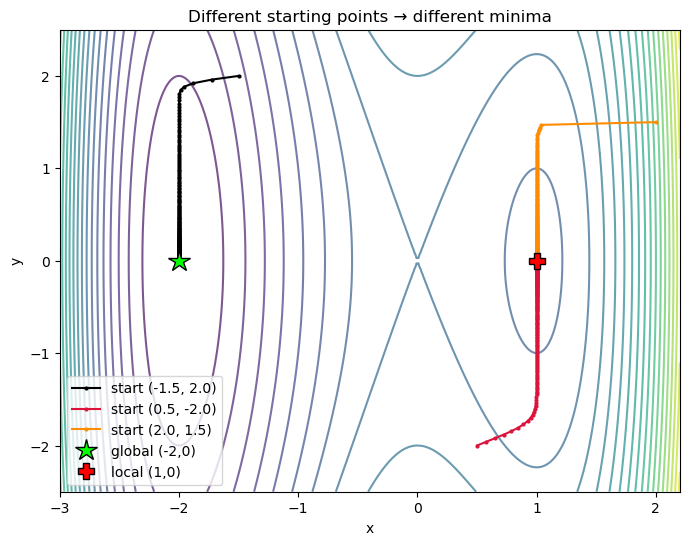

In [5]:
gx = np.linspace(-3, 2.2, 300)
gy = np.linspace(-2.5, 2.5, 300)
X, Y = np.meshgrid(gx, gy)
Z = f_multi(X, Y)

plt.figure(figsize=(8, 6))
cs = plt.contour(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
colors = ["black", "crimson", "darkorange"]
for p, c, s in zip(paths, colors, starts):
    plt.plot(p[:, 0], p[:, 1], "o-", color=c, markersize=2, label=f"start {s}")
plt.plot(-2, 0, "*", color="lime", markersize=16, markeredgecolor="black", label="global (-2,0)")
plt.plot(1, 0, "P", color="red", markersize=11, markeredgecolor="black", label="local (1,0)")
plt.title("Different starting points → different minima")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 7. Exercises

### Basic
1. Write the 2D gradient-descent update rule and name each symbol.
2. Why do we step along $-\nabla f$ instead of $+\nabla f$?

### Intermediate
3. For the sauna, compute the gradient at $(0.5, 0.6)$ by hand and verify the next point
   is $(0.5057, 0.6047)$ with $\alpha = 0.05$.
4. Run sauna gradient descent from $(5.5, 5.5)$. Does it still reach $(4, 4)$?

### Advanced
5. For $f(x,y)=3x^4+4x^3-12x^2+y^2$, run gradient descent from $(-0.1, 0)$ and from
   $(0.1, 0)$. Explain why such close starts can reach different minima.
6. Implement random restarts (10 random starts) for the function in Q5 and report how
   many reach the global minimum.

## 8. Solutions / Checks

In [6]:
# 3. by hand at (0.5, 0.6)
g = grad_T(0.5, 0.6)
nxt = np.array([0.5, 0.6]) - 0.05 * g
print(f"3. ∇T(0.5,0.6)=({g[0]:.4f},{g[1]:.4f}) -> next=({nxt[0]:.4f},{nxt[1]:.4f})")

# 4. from (5.5, 5.5)
fin4, _ = gradient_descent_2d(grad_T, (5.5, 5.5), alpha=0.05)
print(f"4. from (5.5,5.5) -> ({fin4[0]:.3f}, {fin4[1]:.3f}), T={T(*fin4):.3f}")

# 5. two close starts
for s in [(-0.1, 0.0), (0.1, 0.0)]:
    fin, _ = gradient_descent_2d(grad_multi, s, alpha=0.01, n_steps=3000)
    print(f"5. start {s} -> ({fin[0]:.3f}, {fin[1]:.3f}) "
          f"{'global' if fin[0] < -1 else 'local'}")

# 6. random restarts
rng = np.random.default_rng(0)
n_global = 0
for _ in range(10):
    s = (rng.uniform(-3, 2), rng.uniform(-2, 2))
    fin, _ = gradient_descent_2d(grad_multi, s, alpha=0.01, n_steps=3000)
    if np.isfinite(fin).all() and fin[0] < -1:
        n_global += 1
print(f"6. {n_global}/10 random restarts reached the global minimum")

3. ∇T(0.5,0.6)=(-0.1134,-0.0935) -> next=(0.5057,0.6047)
4. from (5.5,5.5) -> (4.000, 4.000), T=73.622
5. start (-0.1, 0.0) -> (-2.000, 0.000) global
5. start (0.1, 0.0) -> (1.000, 0.000) local


6. 3/10 random restarts reached the global minimum


## 9. Conclusion

- Gradient descent in two (or more) variables is the **same** algorithm as in 1D, with the
  derivative replaced by the **gradient**:

$$
\mathbf{x}_k = \mathbf{x}_{k-1} - \alpha\,\nabla f(\mathbf{x}_{k-1}).
$$

- The gradient points to **steepest ascent**, so $-\nabla f$ is the fastest way **down**.
- On the sauna, starting at $(0.5, 0.6)$ with $\alpha = 0.05$ the iterates march to the
  coldest point $(4, 4)$.
- The 1D drawbacks remain — **local minima** — and the same fix applies: **multiple random
  starts**, keeping the best result (no guarantee, but usually a good solution).
- This is the core optimization routine behind training machine-learning models.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradient_5.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture defining **gradient descent in two variables**. Key spoken
points, lightly cleaned:

> Replace the random steps with an exact method. Start at $(x_0, y_0)$. With two variables
> there are two tangents; draw each gradient component as a vector on the floor (steep →
> big vector, flat → small), and their sum is the gradient. The gradient is the direction
> of steepest ascent, so to get colder take the negative gradient — the direction that in
> one tiny step takes you to the coldest nearby point — scaled by the learning rate. Thus
> $(x_1, y_1) = (x_0, y_0) - \alpha\,\nabla f$, exactly like one variable but with the
> gradient instead of the derivative. For the sauna $T = 85 - \tfrac1{90}x^2(x-6)y^2(y-6)$
> starting at $(0.5, 0.6)$ with $\alpha = 0.05$, the gradient gives the next point
> $(0.5057, 0.6047)$, and repeating many times reaches the minimum fast. The algorithm:
> pick $\alpha$ and a start, update $\mathbf{x}_k = \mathbf{x}_{k-1} - \alpha\nabla f$,
> repeat until movement is tiny. Like 1D, it can get stuck in local minima; starting from
> several different places reaches the global minimum with high probability, though never
> with certainty.